# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Load the MNase data for a cycling window:

from src.chromatin_model import read_chromosome_mnase_reads
from src.global_config import GlobalConstants

chr_reads = read_chromosome_mnase_reads(chr=16, replicate=1)
mnase_span = (771600, 771900)

locus_reads = chr_reads[(chr_reads.mid > mnase_span[0]) & 
                        (chr_reads.mid < mnase_span[1])]


In [3]:
from src.chromatin_model import create_exact_bins, downsample_bins, normalize_bins_by_len

timepoints = GlobalConstants.CHROM_WT1_TIMEPOINTS
exact_bins = create_exact_bins(locus_reads, mnase_span, timepoints)
normalized_bins = normalize_bins_by_len(1, exact_bins, log=False)


In [5]:
downsampled_bins = downsample_bins(normalized_bins, mnase_span, GlobalConstants.BIN_WIDTH, 
    GlobalConstants.BIN_HEIGHT, GlobalConstants.MAX_Y_LEN, timepoints)

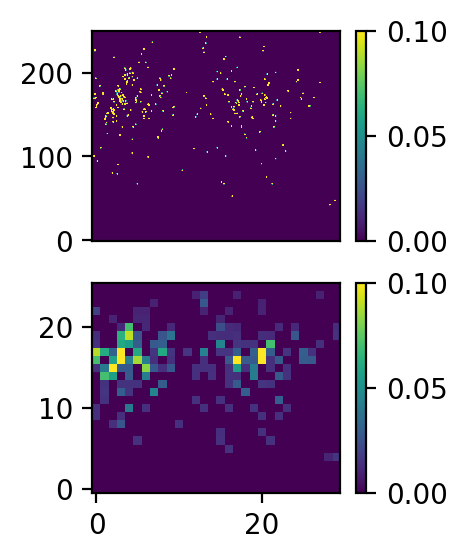

In [6]:
fig = plt.figure(figsize=(2, 3))
plt.subplot(2, 1, 1)
plt.imshow(exact_bins[0], vmax=0.1, vmin=0, aspect='auto', origin='lower')
plt.colorbar()
plt.xticks([])

plt.subplot(2, 1, 2)
plt.imshow(downsampled_bins[0], vmax=0.1, vmin=0, aspect='auto', origin='lower')
plt.colorbar()

In [7]:
from src.deconvolution_solver import DeconvolutionSolver
from src.config import load_default_chrom_configs
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

config, _ = load_default_chrom_configs()
#config.shift_parameters_for_alpha()

config.params_dic.update({
    'mu0': 9.361663,
    'lambda': 60.397553,
    'delta': 14.577271,
    'sigma0': 5.884135,
    'sigmav': 0.044401,
    'gamma1': 0.586077,
    'gamma2': 1.000000,
    'halted': 0.000050,  
})

config.update_timepoints()
H = config.calculate_H()

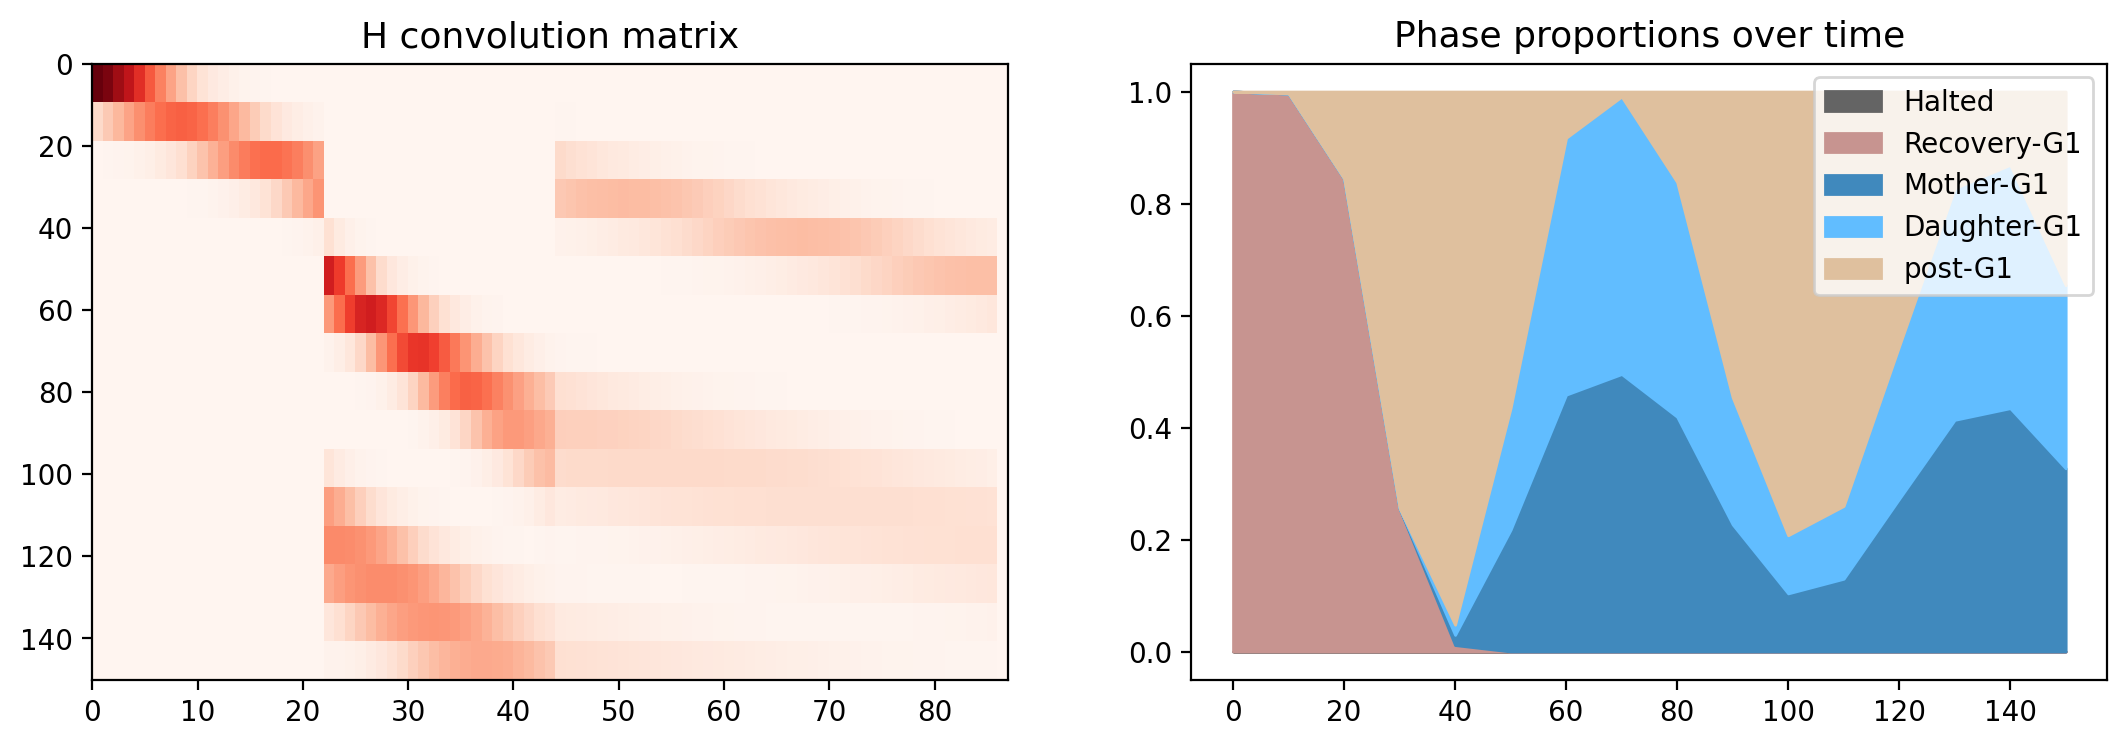

In [8]:
config.plot_H()

In [11]:
padding_type = 'none'

b = 1

chr4_n = np.array([1.00442364, 1.00347336, 0.97773201, 0.8061213 , 0.66388052,
       0.84322967, 0.99955218, 1.00893152, 0.97884289, 0.85742082,
       0.75599297, 0.76982516, 0.84182678, 0.97059662, 0.99078551,
       0.91119956])

chr4_N_test = np.diag(chr4_n)

sample_f_replication = np.array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 1.])

G = downsampled_bins.reshape((downsampled_bins.shape[0], -1))
selected_examples_G = G[:, [493]]

In [590]:
chromatin_solver = ChromatinDeconvolveSolver(config, config.H, 
    selected_examples_G, chr4_N_test, b, sample_f_replication, padding_type=padding_type)

gamma_sweep = np.linspace(0.001, 0.01, 40)
sns = []
rns = []
Fs = np.zeros((len(gamma_sweep), H.shape[1]))

from src.timer import Timer

timer = Timer()
for i, gamma in enumerate(gamma_sweep):
    F = chromatin_solver.deconvolve_G_iteratively(gamma=gamma, verbose=False,
                                                 verbose_progress=False)
    rns.append(chromatin_solver.rn)
    sns.append(chromatin_solver.sn)
    Fs[i] = F.flatten()

gamma_sweep_results_df = pd.DataFrame({'rn': rns, 'sn': sns}, index=gamma_sweep)
timer.print_time()

00:00:01.965


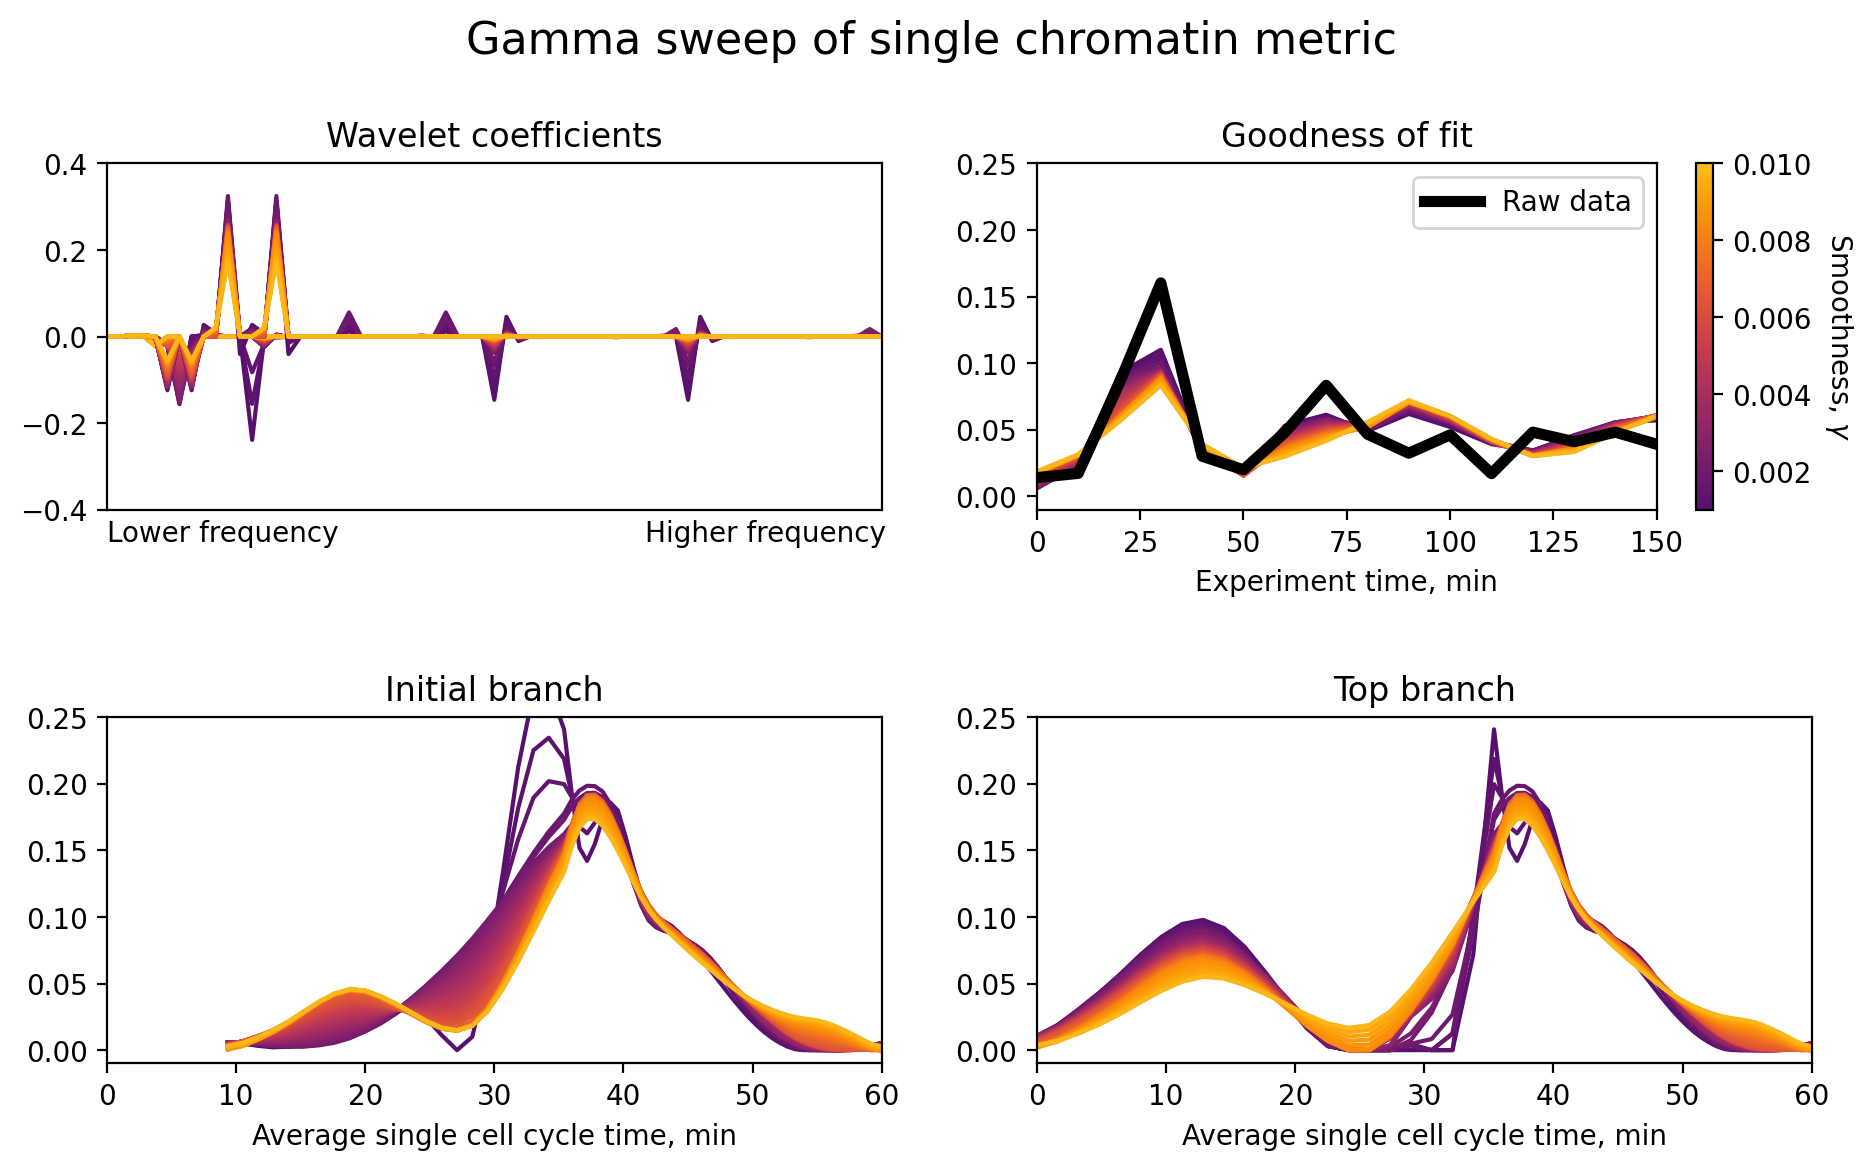

In [656]:
from src.chromatin_gamma_search import create_gamma_sweep_plots_single_measure

create_gamma_sweep_plots_single_measure(config, chr4_N_test, config.H, Fs, sample_f_replication,
    gamma_sweep, selected_examples_G, ylims=(-0.01, 0.25))

0.003538461538461539

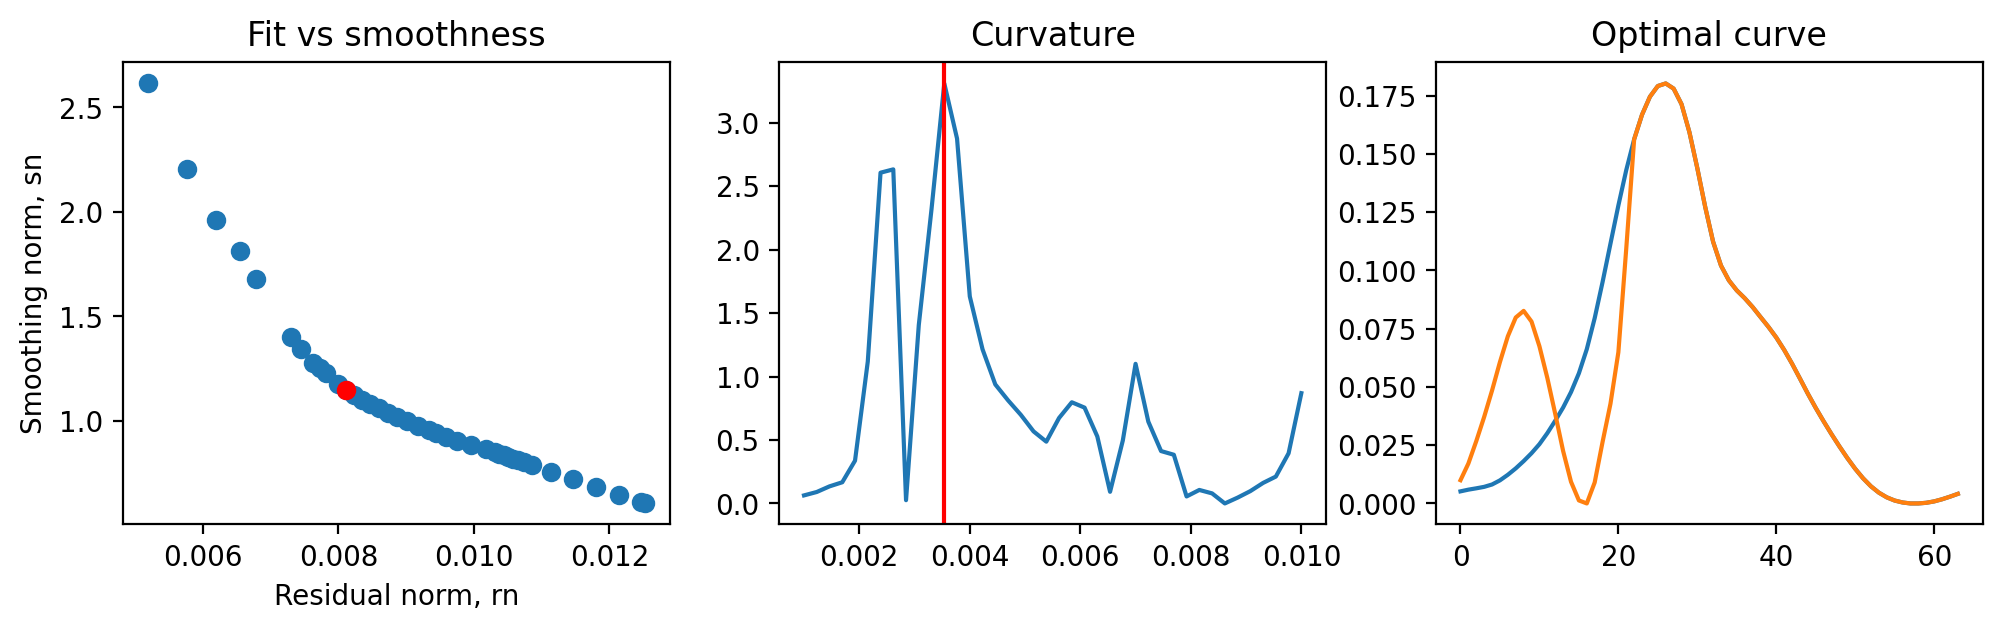

In [671]:
from src.chromatin_gamma_search import find_elbow_point

res = find_elbow_point(gamma_sweep_results_df.rn.values, gamma_sweep_results_df.sn.values,
               gamma_sweep_results_df.index)
optimal_gm = res[2]
optimal_index = res[3]
curvature = res[4]

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.scatter(gamma_sweep_results_df.rn, gamma_sweep_results_df.sn)
plt.scatter(gamma_sweep_results_df.rn.loc[optimal_gm], 
    gamma_sweep_results_df.sn.loc[optimal_gm], c='red')
plt.title("Fit vs smoothness")
plt.xlabel("Residual norm, rn")
plt.ylabel("Smoothing norm, sn")

plt.subplot(1, 3, 2)
plt.plot(gamma_sweep_results_df.index, res[4])
plt.axvline(optimal_gm, c='red')
plt.title("Curvature")

plt.subplot(1, 3, 3)
plt.plot(Fs[optimal_index, i_indices], label="Initial")
plt.plot(Fs[optimal_index, t_indices], label="Top")
plt.title("Optimal curve")
optimal_gm

In [660]:
chromatin_solver = ChromatinDeconvolveSolver(config, config.H, 
    G, chr4_N_test, b, sample_f_replication, padding_type=padding_type)
full_deconvolved_F = chromatin_solver.deconvolve_G_iteratively(
    gamma=optimal_gm)

0/780 - 00:00:00.060
500/780 - 00:00:29.666


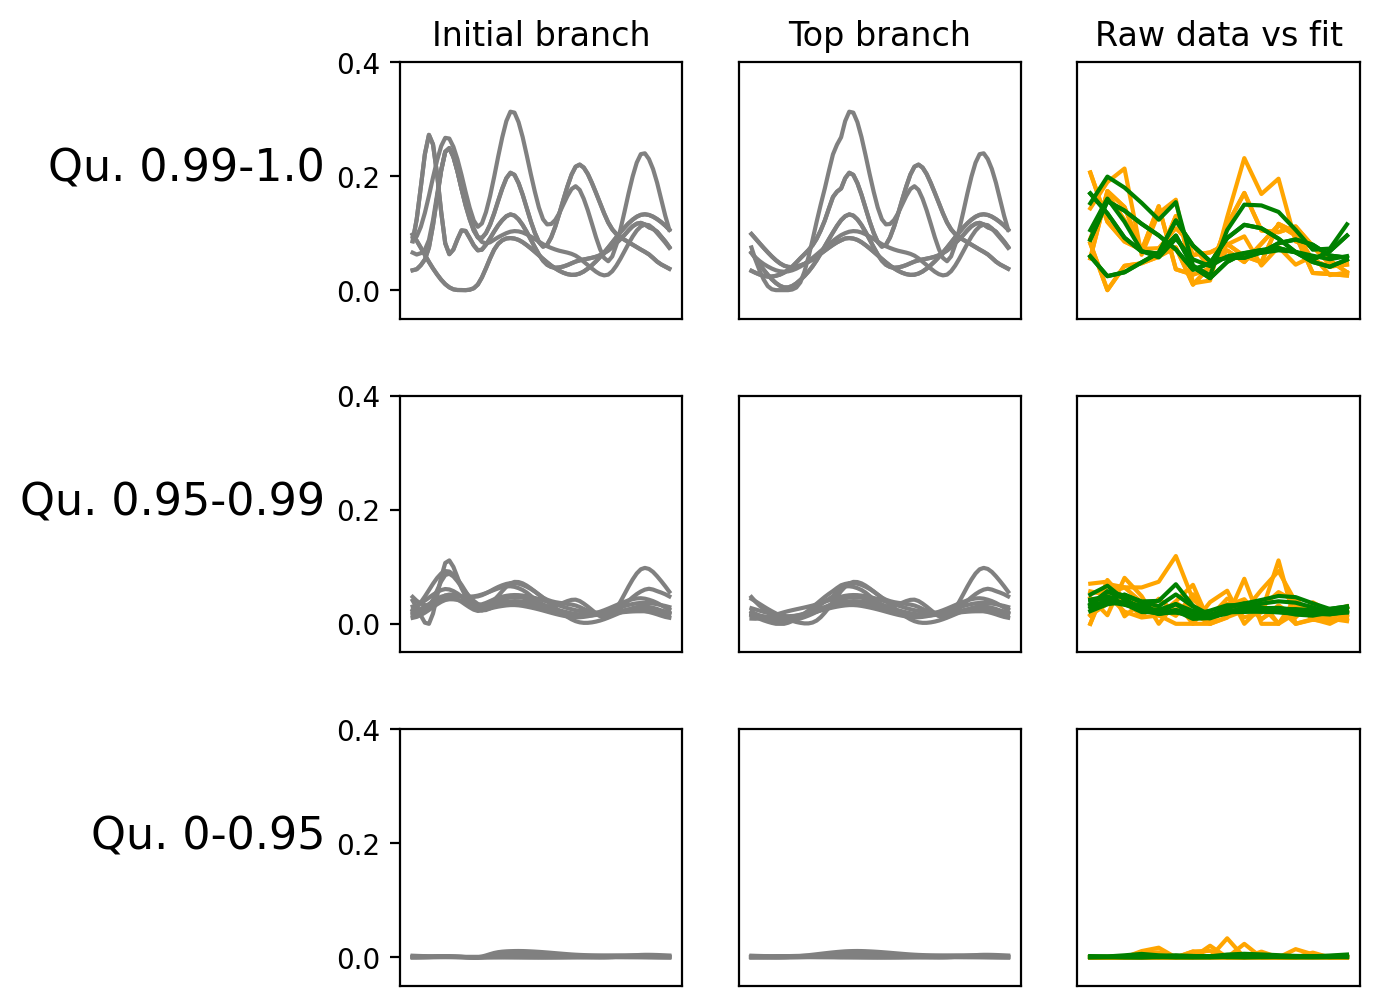

In [673]:
def plot_indices(axs, config, indices, F, F_rep, G, N, b, ylims=(0, 0.5),
                hide_x_axis=True):

    axs[0].plot(F[i_indices, :][:, indices], c='gray')
    axs[0].set_ylim(*ylims)


    axs[1].plot(F[t_indices, :][:, indices], c='gray')
    axs[1].set_ylim(*ylims)
    axs[1].set_yticks([])
    
    H = config.H
    predicted_G = N@H@(F*F_rep[:, None])*b
    
    axs[2].plot(config.timepoints, G[:, indices], c='orange')
    axs[2].plot(config.timepoints, predicted_G[:, indices], c='green')
    axs[2].set_ylim(*ylims)
    axs[2].set_yticks([])
        
    if hide_x_axis:
        for ax in axs:
            ax.set_xticks([])

def select_indices_mean_quantile(F, quantile_boundaries=[0.25, 0.5, 0.75], random_k=10):
    """
    Improve visualization of the quality of smoothness of the solution F.
    
    Identify subselection of curves in F that fit within desired quantiles. This will
    allow us to view the smoothness of quantiles of different average curve values.
    Randomly select so we aren't drawing 100-1000s of curves for each quantile."""
    
    # Compute the means of each of the curves
    from src.helpers import get_quantile_values
    curve_means = np.mean(F, axis=0)
    F_metrics_df = pd.DataFrame({'curve_mean': curve_means})
    
    # Segment them into quantiles
    segments, qvals, lengths = get_quantile_values(F_metrics_df.curve_mean, 
        q=quantile_boundaries)
    
    np.random.seed(123)
    
    random_sets = []
    for i, segment_set in enumerate(segments):
        # Select the indices not the actual values so we can subset the 
        # full curve
        random_set = np.random.choice(segment_set.index, size=random_k)
        random_sets.append(random_set)

    return random_sets

qvals = [0, 0.95, 0.99, 1.0]

# Get the list of indices for the desired quantiles
quantile_segment_indices = select_indices_mean_quantile(full_deconvolved_F,
    quantile_boundaries=qvals[1:-1], random_k=8)

fig, axs = plt.subplots(len(quantile_segment_indices), 3, figsize=(12, 6))
axs = np.flip(np.array(axs), axis=0)

for i, ax_row in enumerate(axs):
    is_top_row = i == len(axs)-1 #bottom to top, because of flip

    plot_indices(ax_row, config, quantile_segment_indices[i], full_deconvolved_F,
                sample_f_replication, G, chr4_N_test, 1, ylims=(-0.05, 0.4),
                hide_x_axis=True)
    ax_row[0].set_ylabel(f"Qu. {qvals[i]}-{qvals[i+1]}", fontsize=16,
                        rotation=0, ha='right')
    if is_top_row:
        ax_row[0].set_title("Initial branch")
        ax_row[1].set_title("Top branch")
        ax_row[2].set_title("Raw data vs fit")

plt.subplots_adjust(hspace=0.3, left=0.5)


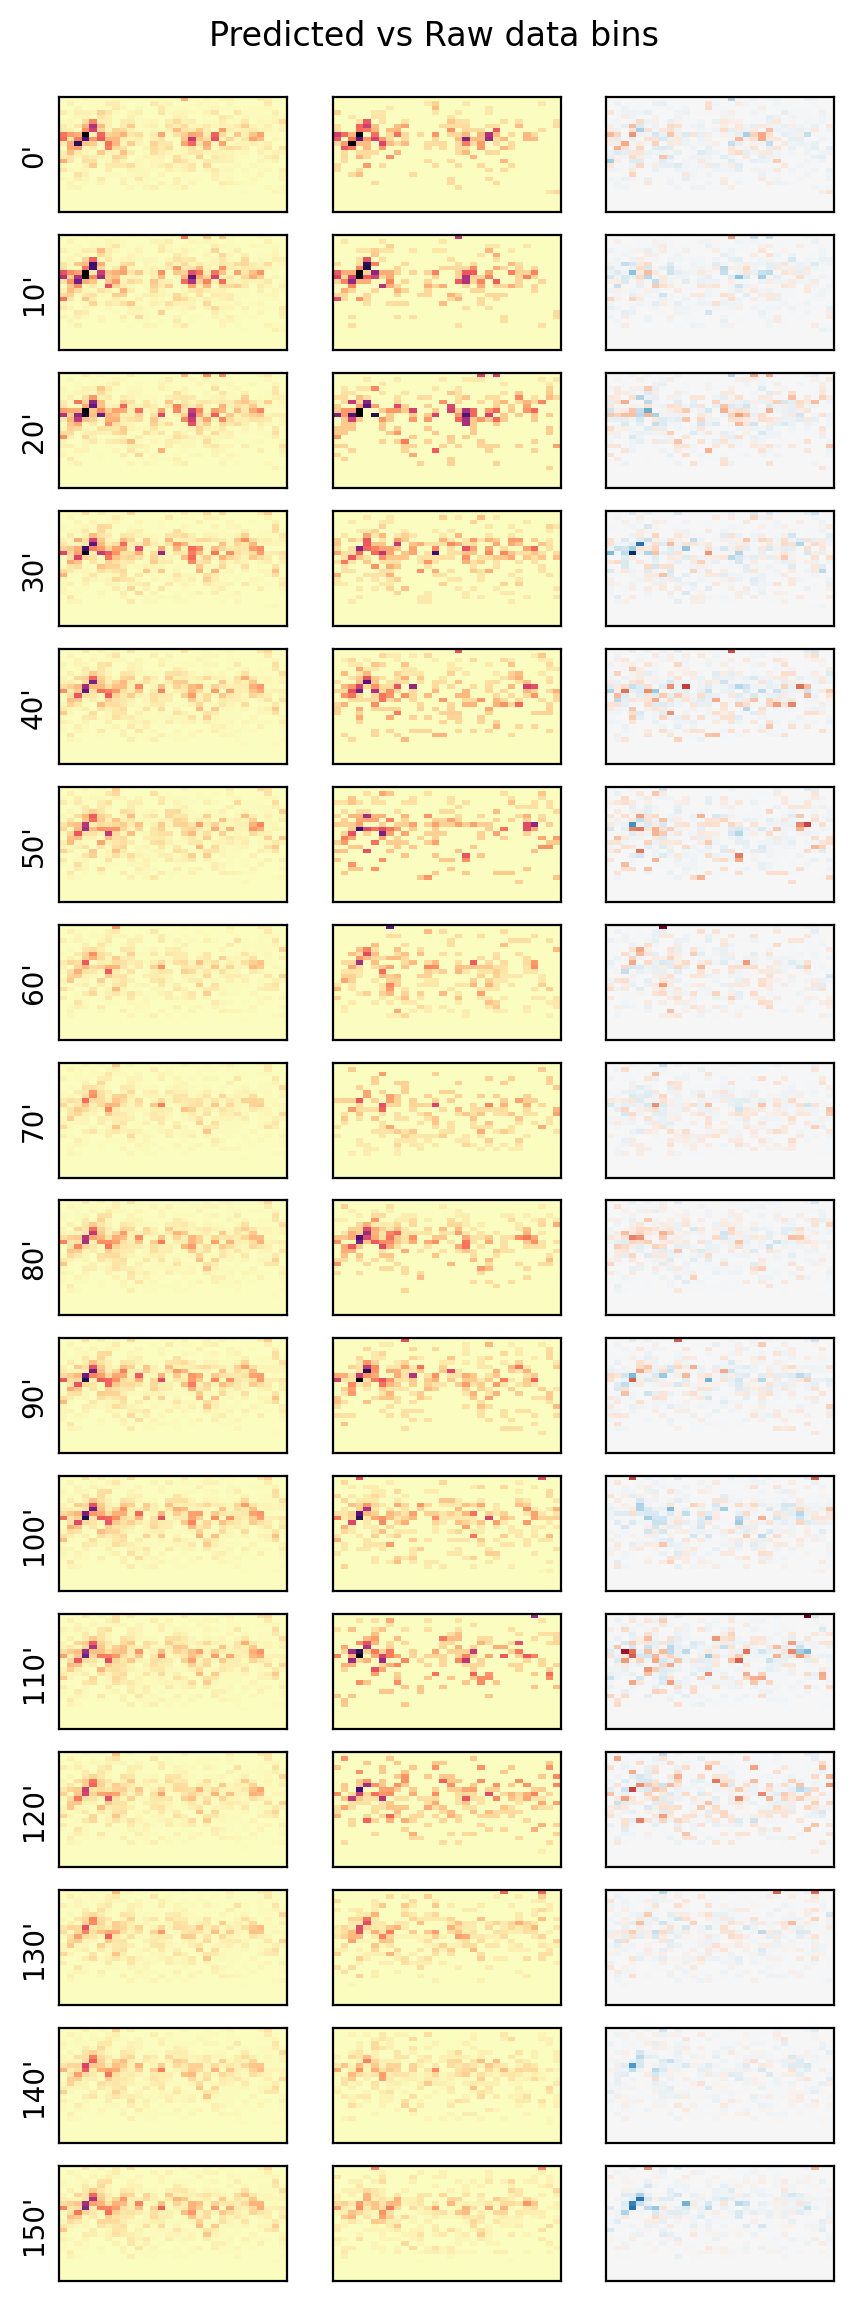

In [662]:
from src.chromatin_model import plot_prediction

plot_prediction(config, chr4_N_test, full_deconvolved_F, sample_f_replication, G, b)

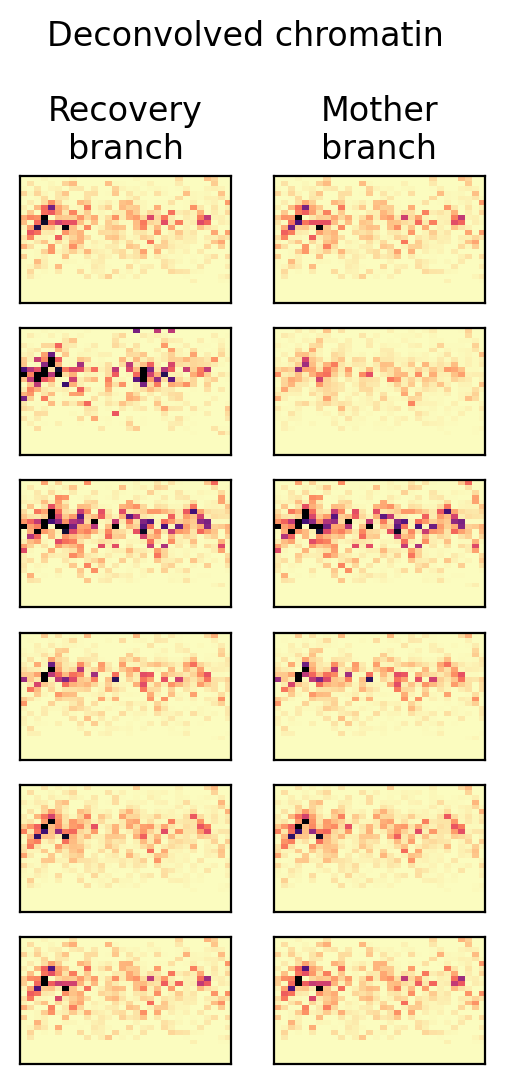

In [663]:
full_F_imgs = full_deconvolved_F.reshape((full_deconvolved_F.shape[0], 26, -1))
full_F_imgs.shape

num_imgs_per_branch = 6

fig, axs = plt.subplots(num_imgs_per_branch, 2, figsize=(3, 6))
axs = np.array(axs).T

def plot_branch_imgs(row_axs, t_indices):

    for plot_index, index_in_t in enumerate(np.linspace(0, len(t_indices)-1, num_imgs_per_branch)):
        image_index = t_indices[int(index_in_t)]

        ax = row_axs[plot_index]
        ax.imshow(full_F_imgs[image_index], aspect='auto', cmap='magma_r', vmax=0.1,
                  origin='lower')
        ax.set_xticks([])
        ax.set_yticks([])
        
plot_branch_imgs(axs[0], i_indices)
plot_branch_imgs(axs[1], t_indices)
axs[0][0].set_title("Recovery\nbranch")
axs[1][0].set_title("Mother\nbranch")
plt.suptitle("Deconvolved chromatin")
plt.subplots_adjust(top=0.85)